# Experiment 1 — ORS vs KL hygiene check

## Why we measure expressivity

A quantum reservoir is a random circuit ensemble $\{U\}$. We say it is
**maximally expressive** when its output states $|\psi_U\rangle = U|0\rangle$
are distributed uniformly over the unit sphere in Hilbert space — i.e. drawn
from the **Haar measure**. Any ensemble that is less expressive is biased
toward some subspace and cannot represent arbitrary functions of the input.

So **expressivity = closeness to Haar**, and the question becomes how to
measure that distance in a scalable way.

---

## The classical baseline: KL divergence on fidelity histograms

Following Sim et al. (2019), one samples many independent state pairs from the
ensemble, computes the fidelities

$$F = |\langle\psi_a | \psi_b\rangle|^2,$$

builds a histogram of the empirical distribution $P_{\text{circuit}}(F)$, and
compares it to the analytical Haar fidelity distribution

$$P_{\text{Haar}}(F) = (D-1)\,(1-F)^{D-2}, \qquad D = 2^n.$$

Closeness to Haar is then quantified by

$$\mathrm{KL}\!\left(P_{\text{circuit}} \,\|\, P_{\text{Haar}}\right).$$

**The problem.** $P_{\text{Haar}}(F)$ is sharply peaked near $F = 0$ with width
$\sim 1/D$. At $n = 12$ that peak has width $\sim 2 \times 10^{-4}$, so resolving it
requires bin widths well below that and far more than $D$ fidelity samples to
populate the bins. KL on fidelities becomes statistically unreliable beyond
$n \approx 8$ — **it does not scale**.

---

## The order-statistics score (ORS, $\Lambda$)

Instead of pairwise fidelities, look at the **sorted output probability
vector** of a single state. For $|\psi_U\rangle$, define
$p_k = |\langle k | \psi_U\rangle|^2$ and sort in descending order:

$$p_{(1)} \geq p_{(2)} \geq \dots \geq p_{(D)}.$$

Each $p_{(k)}$ is the *k*-th **order statistic**. Under Haar, its marginal
density is known in closed form (Micklitz 2025):

$$P_k(x) \propto e^{-k a}\,(1 - e^{-a})^{D-k}, \qquad a = (D-2)\,x.$$

The ORS for one circuit instance is the Haar log-likelihood of the top-$K$
ranks, weighted by $1/k$:

$$\Lambda_s = \sum_{k=1}^{K} \frac{1}{k}\,\log P_k\!\left(p_{(k), s}\right).$$

Averaging over $\mathrm{ns}$ instances gives the ensemble score. **Closer to
the Haar mean → closer to Haar.** Structured ensembles (Clifford, IQP-like)
give scores far below the Haar mean.

### Why this scales when KL does not

| | KL on fidelities | ORS ($\Lambda$) |
|---|---|---|
| Test statistic | full $P(F)$ | top-$K$ sorted $p_{(k)}$ |
| Cost per instance | $O(D)$ | $O(K)$ |
| Sample requirement | $\gg D$ pairs | $\sim 10^2$ instances |
| Scales to $n \geq 10$? | No | Yes |

Two ingredients make the difference. First, the discriminative information
sits in the few largest probabilities; the bulk of $p_{(k)}$ for large $k$ is
floor noise common to every reasonable ensemble. So $K \ll D$ ranks suffice
($K = 50$ by default, capped by support size for stabilizer ensembles).
Second, $\log P_k$ is evaluated analytically at the observed $p_{(k)}$ — no
binning, no bin-width tuning.

---

## What this experiment establishes

We cannot use KL at the scales of interest ($n \geq 10$). We *can* use it at
$n = 6$. The hygiene check is:

> **At $n = 6$, where KL is still reliable, do ORS and KL rank consistently?**

If yes, ORS is a faithful proxy for KL-to-Haar on this regime, and we are
justified in using ORS alone at larger $n$ where KL has broken down. ORS is
not claimed to be *equivalent* to KL — only that the two metrics agree on
which families are more or less Haar-like.


## Step 1: KL Divergence Helpers

These functions implement the KL-divergence expressivity metric from Sim et al. (2019).

- **`fidelity_samples()`** — draws pairs of output states $|\psi_a\rangle, |\psi_b\rangle$ from the ensemble and returns fidelities $F = |\langle\psi_a|\psi_b\rangle|^2$.
- **`haar_fidelity_pdf(F, D)`** — the analytical Haar fidelity distribution $P_{\mathrm{Haar}}(F) = (D-1)(1-F)^{D-2}$, sharply concentrated near $F=0$ with width $\sim 1/D$.
- **`kl_to_haar()`** — bins the empirical fidelity distribution and computes $\mathrm{KL}(P_{\mathrm{circuit}} \| P_{\mathrm{Haar}})$. The histogram approach requires many samples to resolve the narrow Haar peak, which is why KL becomes statistically unreliable beyond $n \approx 8$.

In [2]:
import numpy as np
from qiskit.quantum_info import Statevector
from tqdm import tqdm

def fidelity_samples2(circuit_fn, n_pairs, *, verbose=True):
    """Sample fidelities |<psi_a|psi_b>|^2 for n_pairs independent state pairs.
    
    Each pair = two fresh circuit instances from circuit_fn → two statevectors.
    Returns (n_pairs,) array of fidelities in [0, 1].
    """
    fids = np.empty(n_pairs)
    for i in tqdm(range(n_pairs), desc="fidelity_samples", disable=not verbose):
        psi_a = Statevector(circuit_fn()).data
        psi_b = Statevector(circuit_fn()).data
        fids[i] = np.abs(np.vdot(psi_a, psi_b)) ** 2
    return fids

def fidelity_samples(circuit_fn, n_states, *, verbose=True):
    """Sample n_states statevectors; return ALL pairwise fidelities."""
    Psi = np.empty((2 ** circuit_fn().num_qubits, n_states), dtype=complex)
    for i in tqdm(range(n_states), disable=not verbose):
        Psi[:, i] = Statevector(circuit_fn()).data
    G = np.abs(Psi.conj().T @ Psi) ** 2          # M x M fidelity matrix
    iu = np.triu_indices(n_states, k=1)          # upper triangle, no diagonal
    return G[iu]

def haar_fidelity_pdf(F, D):
    """Analytical Haar fidelity distribution: P(F) = (D-1) (1-F)^(D-2)."""
    F = np.clip(F, 0.0, 1.0)
    return (D - 1) * (1 - F) ** (D - 2)


def kl_to_haar(fids, D, n_bins=75, eps=1e-12):
    """KL(P_circuit || P_Haar) via histogram of fidelities (Sim et al. 2019).
    
    Both PDFs are evaluated on the same bin grid; KL is summed in probability mass:
        KL = Σ_b p_b log(p_b / q_b)
    where p_b is the empirical bin-mass and q_b is the Haar bin-mass.
    """
    edges = np.linspace(0, 1, n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)
    
    # Empirical bin probability mass
    p_emp, _ = np.histogram(fids, bins=edges, density=False)
    p_emp = p_emp.astype(float) / max(len(fids), 1)
    
    # Haar bin probability mass (integrate analytical PDF over each bin via midpoint)
    q_haar = haar_fidelity_pdf(centers, D) * widths
    q_haar /= q_haar.sum()  # renormalise (residual from finite n_bins)
    
    # KL with epsilon guard on both sides
    p_safe = p_emp + eps
    q_safe = q_haar + eps
    p_safe /= p_safe.sum()
    q_safe /= q_safe.sum()
    
    mask = p_emp > 0   # only contribute where empirical mass exists
    return float(np.sum(p_safe[mask] * np.log(p_safe[mask] / q_safe[mask])))

def kl_repeated(circuit_fn, D, n_states, n_bins, n_repeats=5):
    return np.array([
        kl_to_haar(fidelity_samples(circuit_fn, n_states=n_states, verbose=False),
                   D=D, n_bins=n_bins)
        for _ in range(n_repeats)
    ])

print("KL helpers defined.")

KL helpers defined.


## Step 2: Expressivity Sweep — G3 at n=6

We sweep the G3 family (gates drawn from {CNOT, H, T}) over depths $d \in \{2, 5, 10, 20, 50, 100, 200\}$ plus a Haar reference at $n = 6$ qubits ($D = 64$). At this size both KL and ORS are statistically reliable — this is the cross-validation regime.

For each depth we compute:
- **KL divergence** from 1500 statevector samples, repeated 5 times to estimate variance.
- **ORS** $\Lambda$ from 100 circuit instances for $K \in \{1, 2, 4, 8, 16, 32\}$.

Results are cached to `results/ors/results_experiment1.npz` to avoid re-running the sweep.

In [5]:
import os
from metrics import build_circuit, lorentz_curves, order_statistics_score

# ── Cache file ──────────────────────────────────────────────────────────────
RESULTS_FILE = "results/ors/results_experiment1.npz"

# ── Load previous results if available ─────────────────────────────────────
if os.path.exists(RESULTS_FILE):
    print(f"Loading cached results from {RESULTS_FILE}")

    loaded = np.load(RESULTS_FILE, allow_pickle=True)
    results = loaded["results"].item()

else:
    print("No cached results found. Running simulations...")

    # ── Sweep configuration ─────────────────────────────────────────────────
    NQBITS       = 6
    D            = 2 ** NQBITS
    NS_ORS       = 100
    N_STATES      = 1500
    N_KL_REPEATS = 5
    K_VALUES     = [1, 2, 4, 8, 16, 32]
    N_BINS_KL    = 75

    families = [
        ("G3 d=2",     "G3",   dict(depth=2)),
        ("G3 d=5",     "G3",   dict(depth=5)),
        ("G3 d=10",    "G3",   dict(depth=10)),
        ("G3 d=20",    "G3",   dict(depth=20)),
        ("G3 d=50",    "G3",   dict(depth=50)),
        ("G3 d=100",   "G3",   dict(depth=100)),
        ("G3 d=200",   "G3",   dict(depth=200)),
        ("Haar",       "Haar", dict(haar_mode="statevector")),
    ]

    # ── Run sweep ───────────────────────────────────────────────────────────
    results = {}

    for label, name, kwargs in families:

        print(f"→ {label}")

        fn = build_circuit(name, NQBITS, **kwargs)

        # ORS sampling
        _, sorted_probs, _ = lorentz_curves(fn, NQBITS, nshots=0, ns=NS_ORS, verbose=False )

        # KL repeated evaluations
        kls = kl_repeated(fn, D=D, n_states=N_STATES, n_bins=N_BINS_KL, n_repeats=N_KL_REPEATS)

        # ORS for different K
        ors_by_k = {}

        for K in K_VALUES:
            ors = order_statistics_score( sorted_probs,D=D, K=K )
            ors_by_k[K] = {
                "mean": float(np.mean(ors)),
                "std":  float(np.std(ors)),
            }

        results[label] = {
            "ors_by_k": ors_by_k,
            "kl":       float(kls.mean()),
            "kl_std":   float(kls.std()),
            "kl_runs":  kls,
        }

        summary = "  ".join(
            f"K={K}: {ors_by_k[K]['mean']:+.2f}"
            for K in K_VALUES)

        print(f"   KL = {kls.mean():.4f} ± {kls.std():.4f}   {summary}")

    # ── Save compressed results ────────────────────────────────────────────
    np.savez_compressed(
        RESULTS_FILE,
        results=results
    )

    print(f"Results saved to {RESULTS_FILE}")

Loading cached results from results/ors/results_experiment1.npz


## Calculate exact Haar value for ORS(K)

In [6]:
from metrics import lambda_haar_exact, lambda_haar_largeD

K_ors = 4
nqbits = 6
D = 2 ** nqbits
Lambda_Haar_approx = lambda_haar_largeD(D, K_ors)
Lambda_Haar_exact = lambda_haar_exact(D, K_ors)
print(f"Haar λ (approx) = {Lambda_Haar_approx:.6f}")
print(f"Haar λ (exact)  = {Lambda_Haar_exact:.6f}")

Haar λ (approx) = 5.975389
Haar λ (exact)  = 6.485196


## Step 3: KL vs ORS Comparison Plot

Both metrics are plotted against G3 circuit depth. The left axis (red) shows KL divergence to Haar; each right axis (colour) shows $\Lambda$ for one value of $K$. Dotted horizontal lines mark the respective Haar references ($\mathrm{KL} = 0$; $\Lambda = \Lambda^{\mathrm{Haar}}$).

Both metrics should converge monotonically toward Haar, with the transition occurring in the same depth range $d \in [10, 20]$ across all $K$ — confirming that ORS and KL agree on which families are more or less Haar-like.

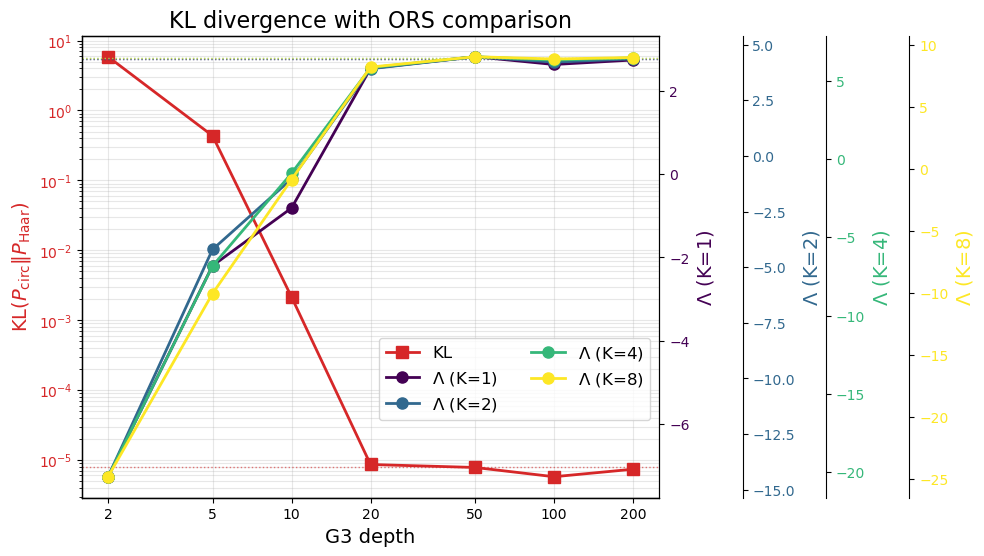

In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, NullLocator

# ── Extract data ────────────────────────────────────────────────────────────
g3_items  = [(lab, r) for lab, r in results.items() if lab.startswith("G3")]
haar_item = next(((lab, r) for lab, r in results.items() if lab.startswith("Haar")), None)
 
def _depth_of(label):
    return int(label.split("d=")[1])
g3_items.sort(key=lambda kv: _depth_of(kv[0]))

depths = np.array([_depth_of(lab) for lab, _ in g3_items])
kl_g3  = np.array([r["kl"] for _, r in g3_items])

# ── Plot: KL on the left axis, one ORS axis per K on the right ──────────────
fig, ax_kl = plt.subplots(figsize=(11, 6))

# KL on the primary (left) axis
kl_color = "tab:red"
ax_kl.plot(depths, kl_g3, 's-', color=kl_color, lw=2, ms=8,
           label="KL", zorder=5)
if haar_item is not None:
    ax_kl.axhline(haar_item[1]["kl"], color=kl_color, ls=':', lw=1, alpha=0.6)
ax_kl.set_xscale("log")
ax_kl.set_xticks(depths)
ax_kl.get_xaxis().set_major_formatter(ScalarFormatter())
ax_kl.get_xaxis().set_minor_locator(NullLocator())

ax_kl.set_yscale("log")
ax_kl.set_xlabel("G3 depth", fontsize=14)
ax_kl.set_ylabel(r"KL$(P_{\mathrm{circ}} \| P_{\mathrm{Haar}})$", color=kl_color, fontsize=14)
ax_kl.tick_params(axis='y', labelcolor=kl_color)
ax_kl.grid(alpha=0.3, which='both')


ors_axes = []
K_VALUES_SMALL = [1, 2, 4, 8,]
# One twin axis per K, offset progressively to the right
cmap = plt.cm.viridis
colors = [cmap(i / max(len(K_VALUES_SMALL) - 1, 1))
          for i in range(len(K_VALUES_SMALL))]

for idx, (K, color) in enumerate(zip(K_VALUES_SMALL, colors)):
    ax = ax_kl.twinx()
    # Offset each new axis 60 pts further right
    ax.spines["right"].set_position(("outward", 60 * idx))

    ors_g3   = np.array([r["ors_by_k"][K]["mean"] for _, r in g3_items])
    ors_g3_s = np.array([r["ors_by_k"][K]["std"]  for _, r in g3_items])
    ax.plot(depths, ors_g3, 'o-',
                color=color, lw=2, ms=8,
                label=f"$\\Lambda$ (K={K})")
    #ax.errorbar(depths, ors_g3, yerr=ors_g3_s, fmt='o-',
    #            color=color, lw=1.6, ms=6, capsize=3,
    #            label=f"$\\Lambda$ K={K}")

    if haar_item is not None:
        haar_ors = haar_item[1]["ors_by_k"][K]["mean"]
        ax.axhline(haar_ors, color=color, ls=':', lw=1, alpha=0.6)

    ax.set_ylabel(rf"$\Lambda$ (K={K})", color=color, fontsize=14)
    ax.tick_params(axis='y', labelcolor=color)
    ors_axes.append(ax)

# Combined legend (gather handles from all axes)
handles, labels = ax_kl.get_legend_handles_labels()
for ax in ors_axes:
    h, l = ax.get_legend_handles_labels()
    handles += h
    labels  += l
ax_kl.legend(handles, labels, 
             bbox_to_anchor=(0.5, 0.15), fontsize=12, ncol=2)

ax_kl.set_title(f"KL divergence with ORS comparison", fontsize=16)

# Generous right margin to fit the stacked axes
plt.subplots_adjust(right=0.65)
plt.show()

## Step 4: Local Scaling Law — $\mathrm{KL} \propto (\Delta\Lambda)^2$

Near Haar, the project plan predicts:

$$\mathrm{KL} \approx \frac{\kappa}{\lambda^2}\,(\Delta\Lambda)^2 + O\!\left((\Delta\Lambda)^3\right), \qquad \Delta\Lambda = \Lambda^{\mathrm{Haar}} - \Lambda.$$

In log-log space, this predicts a slope of **2**. We fit the slope empirically for each $K$ and compare against the theoretical value. A fitted slope close to 2 confirms that ORS behaves as a linear proxy for $\sqrt{\mathrm{KL}}$, justifying its use as a scalable surrogate at large $n$ where KL cannot be computed.

   K     slope        R²   (d >= 3)
   1     1.759    0.7442
   2     2.517    0.8636
   4     2.247    0.8472
   8     1.994    0.8248
  16     0.786    0.5265
  32     1.694    0.7512

K = 4 sweep  (d >= 3):
 depth           KL      Λhaar−Λ   used?
     2      5.87590     26.72129      no
     5      0.43510     13.26924     yes
    10      0.00215      7.35295     yes
    20      0.00001      0.60608     yes
    50      0.00001     -0.09175      no
   100      0.00001      0.12710     yes
   200      0.00001     -0.01800      no


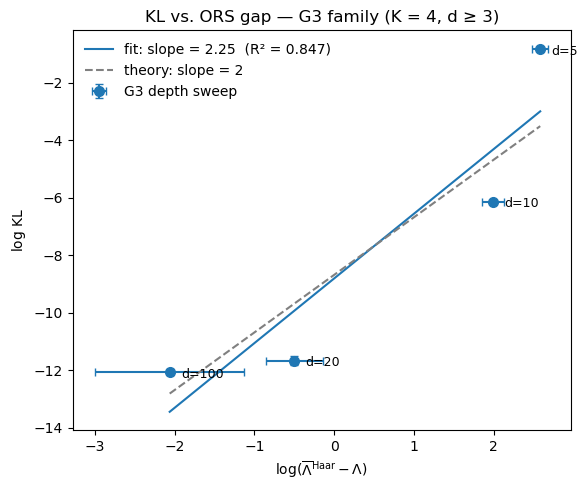

In [8]:
import numpy as np
import matplotlib.pyplot as plt

HAAR_REF  = "Haar"
SWEEP     = [lbl for lbl, name, _ in families if name == "G3"]
MIN_DEPTH = 3


def kl_vs_ors_gap(results, K, sweep=SWEEP, haar_ref=HAAR_REF,
                  ns_ors=NS_ORS, n_kl_repeats=N_KL_REPEATS,
                  min_depth=MIN_DEPTH):
    """Extract (depth, KL, ORS-gap) per family and fit log KL vs log gap.
    Only depths >= min_depth enter the fit."""
    lam_haar = results[haar_ref]["ors_by_k"][K]["mean"]
    haar_sem = results[haar_ref]["ors_by_k"][K]["std"] / np.sqrt(ns_ors)

    rows = []
    for label in sweep:
        r       = results[label]
        depth   = int(label.split("d=")[1])
        lam     = r["ors_by_k"][K]["mean"]
        lam_sem = r["ors_by_k"][K]["std"] / np.sqrt(ns_ors)

        gap     = lam_haar - lam                       # Λ_Haar − Λ  (≥ 0)
        gap_sem = np.hypot(lam_sem, haar_sem)
        kl      = r["kl"]
        kl_sem  = r["kl_std"] / np.sqrt(n_kl_repeats)
        rows.append((depth, kl, kl_sem, gap, gap_sem))

    depth, kl, kl_sem, gap, gap_sem = map(np.array, zip(*rows))

    # keep depths >= min_depth (and avoid log of non-positive values)
    mask = (depth >= min_depth) & (gap > 0) & (kl > 0)
    x, y = np.log(gap[mask]), np.log(kl[mask])

    if mask.sum() >= 2:
        slope, intercept = np.polyfit(x, y, 1)
        resid = y - (slope * x + intercept)
        r2 = 1 - np.sum(resid**2) / np.sum((y - y.mean())**2)
    else:
        slope = intercept = r2 = np.nan

    return dict(depth=depth, kl=kl, kl_sem=kl_sem, gap=gap, gap_sem=gap_sem,
                mask=mask, slope=slope, intercept=intercept, r2=r2)


# ── Robustness check: fitted slope for every K (theory: slope = 2) ──────────
print(f"{'K':>4} {'slope':>9} {'R²':>9}   (d >= {MIN_DEPTH})")
for K in K_VALUES:
    f = kl_vs_ors_gap(results, K)
    print(f"{K:>4} {f['slope']:>9.3f} {f['r2']:>9.4f}")

# ── Main diagnostic plot for K = 4 (paper default) ──────────────────────────
K_PLOT = 4
f = kl_vs_ors_gap(results, K_PLOT)
m   = f["mask"]
x, y = np.log(f["gap"][m]), np.log(f["kl"][m])

print(f"\nK = {K_PLOT} sweep  (d >= {MIN_DEPTH}):")
print(f"{'depth':>6} {'KL':>12} {'Λhaar−Λ':>12} {'used?':>7}")
for d, kl_, g, used in zip(f["depth"], f["kl"], f["gap"], f["mask"]):
    print(f"{d:>6} {kl_:>12.5f} {g:>12.5f} {('yes' if used else 'no'):>7}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.errorbar(x, y,
            xerr=f["gap_sem"][m] / f["gap"][m],
            yerr=f["kl_sem"][m]  / f["kl"][m],
            fmt="o", ms=7, capsize=3, color="C0", label="G3 depth sweep")

for xi, yi, d in zip(x, y, f["depth"][m]):
    ax.annotate(f"d={d}", (xi, yi), textcoords="offset points",
                xytext=(8, -4), fontsize=9)

xfit = np.linspace(x.min(), x.max(), 100)
ax.plot(xfit, f["slope"] * xfit + f["intercept"], "-", color="C0",
        label=f"fit: slope = {f['slope']:.2f}  (R² = {f['r2']:.3f})")

x0, y0 = x.mean(), y.mean()
ax.plot(xfit, 2 * (xfit - x0) + y0, "--", color="grey",
        label="theory: slope = 2")

ax.set_xlabel(r"$\log(\overline{\Lambda}^{\mathrm{Haar}} - \Lambda)$")
ax.set_ylabel(r"$\log\,\mathrm{KL}$")
ax.set_title(f"KL vs. ORS gap — G3 family (K = {K_PLOT}, d ≥ {MIN_DEPTH})")
ax.legend(frameon=False)
fig.tight_layout()
plt.savefig("kl_vs_ors_loglog.png", dpi=150)
plt.show()

## Step 5: Scalability Demonstration — ORS at n=20

KL divergence is computationally intractable at $n = 20$ ($D = 2^{20} \approx 10^6$), but ORS can be evaluated from a single statevector sample using the `statevector=True` flag.

We compare:
- **G3** ($n = 20$, 1000 gates) — expected near Haar ($\Lambda \approx \Lambda^{\mathrm{Haar}}$).
- **G1** ($n = 20$, 1000 gates) — Clifford-only gate set {CNOT, H, S}, expected far below Haar.

A strongly negative $\Lambda$ score for G1 confirms that ORS discriminates expressivity levels even at qubit sizes where KL is infeasible.

In [9]:
from QELM import QuantumCircQiskit
from metrics import lorentz_curves, order_statistics_score, lambda_haar_largeD
import matplotlib.pyplot as plt
import numpy as np

nqbits = 20
num_gates = 1000
K_ors = 4

qrc = QuantumCircQiskit('G3', nqbits = nqbits, num_gates = num_gates)
cumsum_probs, sorted_probs, _ = lorentz_curves(qrc.get_reservoir, nqbits, 1e7, 1, verbose=True, statevector = True)
lam = order_statistics_score(sorted_probs, 2**nqbits, K=K_ors)[0]

lam_exact = lambda_haar_largeD(2**nqbits, K_ors)
print(f"ORS λ = {lam:.6f}")
print(f"Exact λ = {lam_exact:.6f}")

lorentz_curves: 100%|██████████| 1/1 [00:00<00:00,  1.44it/s]

ORS λ = 24.281762
Exact λ = 26.226612


In [10]:
qrc_G1 = QuantumCircQiskit('G1', nqbits = nqbits, num_gates = num_gates)
cumsum_probs_G1, sorted_probs_G1, _ = lorentz_curves(qrc_G1.get_reservoir, nqbits, 1e7, 1, verbose=True, statevector = True)
lam_G1 = order_statistics_score(sorted_probs_G1, 2**nqbits, K=K_ors)[0]

print(f"ORS λ = {lam_G1:.6f}")
print(f"Exact λ = {lam_exact:.6f}")

lorentz_curves:   0%|          | 0/1 [00:00<?, ?it/s]

lorentz_curves: 100%|██████████| 1/1 [00:00<00:00,  1.66it/s]

ORS λ = -317585.614564
Exact λ = 26.226612


## Step 6: Noisy ORS Statistic

Hardware circuits are affected by gate errors and readout noise. We model this via a global depolarising fidelity $f \in [0, 1]$, where $f = 1$ is noiseless and $f = 0$ is maximally mixed.

The Haar log-likelihood is replaced by a noise-adapted version $\log P_k^{\mathrm{noisy}}(p_{(k)}, f)$, and the Haar baseline shifts to $\Lambda^{\mathrm{Haar},\mathrm{noisy}}(f)$ (see `lambda_haar_largeD_noisy` in `metrics.py`). The **ORS gap** $\Lambda - \Lambda^{\mathrm{Haar},\mathrm{noisy}}(f)$ remains a valid expressivity measure: a gap of zero means the circuit matches the noise level of a Haar-random circuit at fidelity $f$.

The cells below verify that a G3 circuit (1000 gates, $n=6$) tracks the noisy Haar baseline across $f \in [0.1, 1.0]$, confirming the noise model is internally consistent. IBM hardware results are in `Exp - Quantum Hardware.ipynb`.

In [11]:
from QELM import QuantumCircQiskit
from metrics import lorentz_curves_noisy, order_statistics_score_noisy, lambda_haar_largeD_noisy
import matplotlib.pyplot as plt
import numpy as np

nqbits = 6
num_gates = 1000
K_ors = 4
fs = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]
lambdas = []
lambdas_exact = []

qrc = QuantumCircQiskit('G3', nqbits = nqbits, num_gates = num_gates)
for f in fs: 
    cumsum_probs, sorted_probs, _ = lorentz_curves_noisy(qrc.get_reservoir, nqbits, 1e7, 1, fidelity=f, verbose=False, statevector = True)
    lam = order_statistics_score_noisy(sorted_probs, 2**nqbits, K=K_ors, f = f)[0]
    lam_exact = lambda_haar_largeD_noisy(2**nqbits, K_ors, f)
    lambdas.append(lam)
    lambdas_exact.append(lam_exact)
    print(f"f = {f}, λ = {lam:.6f}, λ (exact) = {lam_exact:.6f}")

f = 1.0, λ = 6.336031, λ (exact) = 5.975389
f = 0.9, λ = 6.555532, λ (exact) = 6.194890
f = 0.8, λ = 6.800913, λ (exact) = 6.440272
f = 0.7, λ = 7.079104, λ (exact) = 6.718462
f = 0.6, λ = 7.400251, λ (exact) = 7.039609
f = 0.5, λ = 7.780088, λ (exact) = 7.419446
f = 0.4, λ = 8.244970, λ (exact) = 7.884328
f = 0.3, λ = 8.844308, λ (exact) = 8.483666
f = 0.2, λ = 9.689027, λ (exact) = 9.328385
f = 0.1, λ = 11.133083, λ (exact) = 10.772441


## Step 7: Noisy ORS Across All Families and Qubit Sizes

We apply the noisy ORS analysis to all circuit families for $n \in \{10, 16, 20\}$ and fidelities $f \in \{1.0, 0.5, 0.1\}$.

Pre-computed results are loaded from `results/ors/noisy/`. Each panel shows the ORS gap $\Lambda - \Lambda^{\mathrm{Haar},\mathrm{noisy}}(f)$:
- Gap near **0** → the ensemble is Haar-like at this noise level.
- Strongly negative gap → the ensemble is far from Haar.

**Left column**: gate-based families (G1, G2, G3) swept over number of gates.
**Right column**: IQP-style commuting families (D2_random, D2_random_XZ, D2_random_XZY) swept over expected degree $\bar{d}$.

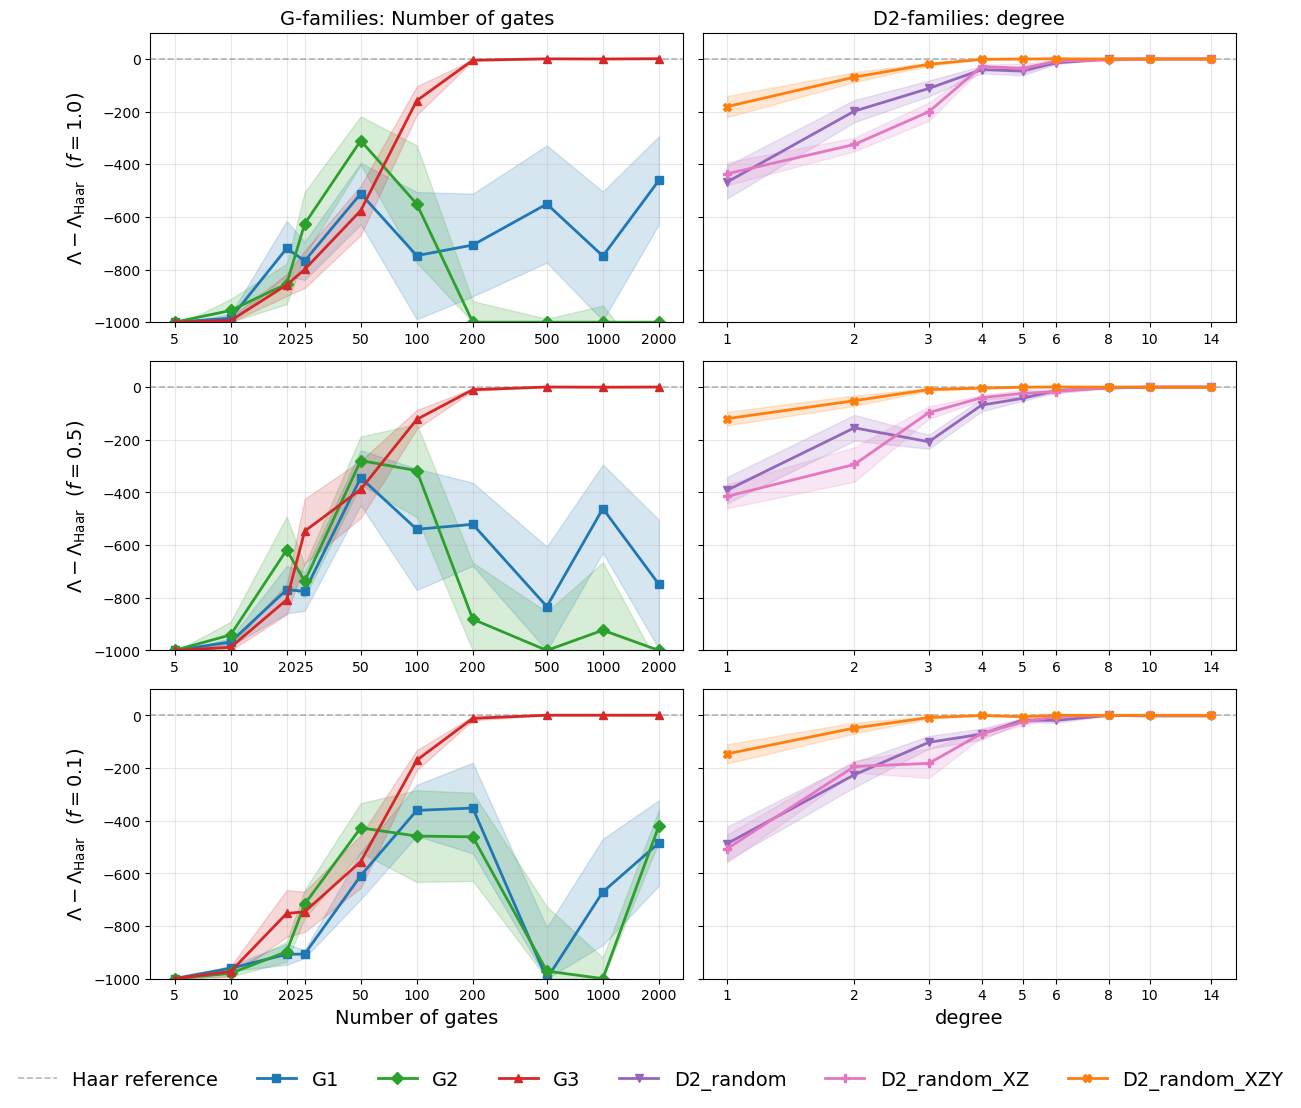

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

RESULTS_FOLDER = 'results/ors/noisy/'

G_FAMILIES  = ['G1', 'G2', 'G3']
D2_FAMILIES = ['D2_random', 'D2_random_XZ', 'D2_random_XZY']

FAMILY_COLORS = {
    'G1': '#1f77b4', 'G2': '#2ca02c', 'G3': '#d62728',
    'D2_random': '#9467bd', 'D2_random_XZ': '#e377c2', 'D2_random_XZY': '#ff7f0e',
}
FAMILY_MARKERS = {
    'G1': 's', 'G2': 'D', 'G3': '^',
    'D2_random': 'v', 'D2_random_XZ': 'P', 'D2_random_XZY': 'X',
}

# Variant sweeps available on disk
G_NUM_GATES = [5, 10, 20, 25, 50, 100, 200, 500, 1000, 2000]
D2_DEGREES  = [1, 2, 3, 4, 5, 6, 8, 10, 14]


def filename(family, kind, value, ns=10, seed=0):
    if kind == 'ng':
        return f"{family}_ng{value}_{ns}runs_seed{seed}.npz"
    elif kind == 'deg':
        return f"{family}_deg{value}_L1_{ns}runs_seed{seed}.npz"


def load_gap(family, kind, value, n, f, K_idx=1, ns=10, seed=0):
    """Return (mean, sem) of Λ - Λ^Haar,noisy(f) for one (family, variant, n, f)."""
    path = os.path.join(RESULTS_FOLDER, filename(family, kind, value, ns, seed))
    if not os.path.exists(path):
        return np.nan, np.nan
    data = np.load(path)
    ftag = f"{float(f):.2f}".replace('.', 'p')
    ors_key  = f"ors_n{int(n)}_f{ftag}"
    haar_key = f"haar_n{int(n)}_f{ftag}"
    if ors_key not in data.files or haar_key not in data.files:
        print('ORS not found')
        return np.nan, np.nan
    ors_vals = data[ors_key][:, K_idx]
    haar_val = data[haar_key][K_idx]
    finite = np.isfinite(ors_vals)
    if finite.sum() == 0:
        return -np.inf, np.nan
    gap = ors_vals[finite] - haar_val
    return gap.mean(), gap.std() / np.sqrt(len(gap))


def collect_family_curve(family, kind, values, n, f, K_idx=1):
    means, sems = [], []
    for v in values:
        m, s = load_gap(family, kind, v, n, f, K_idx)
        means.append(m)
        sems.append(s)
    return np.array(means), np.array(sems)


def plot_ors_complexity_vs_fidelity(
    n=10,
    fs=(1.0, 0.5, 0.1),
    K_idx=1,
    save_path=None,
    ors_floor=-1000.0,   # clip extreme negatives (G1/G2 at high f) for readability
):
    """
    Rows: fidelities. Cols: G-families | D2-families.
    x-axis: number of gates (G) or degree (D2). y-axis: Λ - Λ^Haar,noisy(f).
    """
    if save_path is None:
        save_path = f'figures/fig_ors_complexity_vs_fidelity_n{n}.png'

    nrows = len(fs)
    fig, axes = plt.subplots(nrows, 2, figsize=(12, 3.6 * nrows), sharey='row')
    axes = np.atleast_2d(axes)

    col_specs = [
        ('G-families: Number of gates', G_FAMILIES, 'ng', G_NUM_GATES, 'Number of gates'),
        ('D2-families: degree',         D2_FAMILIES, 'deg', D2_DEGREES, 'degree'),
    ]

    for row, f in enumerate(fs):
        for col, (title, fams, kind, values, xlabel) in enumerate(col_specs):
            ax = axes[row, col]

            # Haar reference at 0 (we subtract the noisy-Haar baseline)
            ax.axhline(0, color='gray', ls='--', lw=1.2, alpha=0.55,
                       label='Haar reference' if (row == 0 and col == 0) else None)

            for fam in fams:
                means, sems = collect_family_curve(fam, kind, values, n, f, K_idx)
                # Clip -inf and very-negative to the floor for plotting
                means_plot = np.where(np.isfinite(means), means, ors_floor)
                means_plot = np.clip(means_plot, ors_floor, None)
                ax.plot(values, means_plot,
                        marker=FAMILY_MARKERS[fam],
                        color=FAMILY_COLORS[fam],
                        lw=2.0,
                        label=fam if row == 0 else None)
                # Only fill where sem is finite
                lo = np.clip(means - sems, ors_floor, None)
                hi = means + sems
                mask = np.isfinite(means) & np.isfinite(sems)
                if mask.any():
                    ax.fill_between(np.array(values)[mask],
                                    lo[mask], hi[mask],
                                    color=FAMILY_COLORS[fam], alpha=0.18)

            ax.set_xscale('log')
            ax.set_ylim(ors_floor, -ors_floor*0.1)
            ax.grid(True, which='both', alpha=0.3)
            ax.set_xticks(values)
            ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
            ax.get_xaxis().set_minor_locator(plt.NullLocator())

            if row == 0:
                ax.set_title(title, fontsize=14)
            if row == nrows - 1:
                ax.set_xlabel(xlabel, fontsize=14)
            if col == 0:
                ax.set_ylabel(rf'$\Lambda - \Lambda_{{\rm Haar}}$  ($f={f}$)',
                              fontsize=14)

    # Single legend at bottom
    handles, labels = [], []
    for ax in axes[0]:
        h, l = ax.get_legend_handles_labels()
        for hh, ll in zip(h, l):
            if ll not in labels:
                handles.append(hh); labels.append(ll)
    fig.legend(handles, labels, loc='upper center',
               bbox_to_anchor=(0.5, -0.01),
               ncol=len(labels), fontsize=14, frameon=False)

    fig.tight_layout(rect=[0, 0, 1, 0.97])
    fig.savefig(save_path, dpi=160, bbox_inches='tight')
    plt.show()


plot_ors_complexity_vs_fidelity(n=10, fs=(1.0, 0.5, 0.1), K_idx=3)

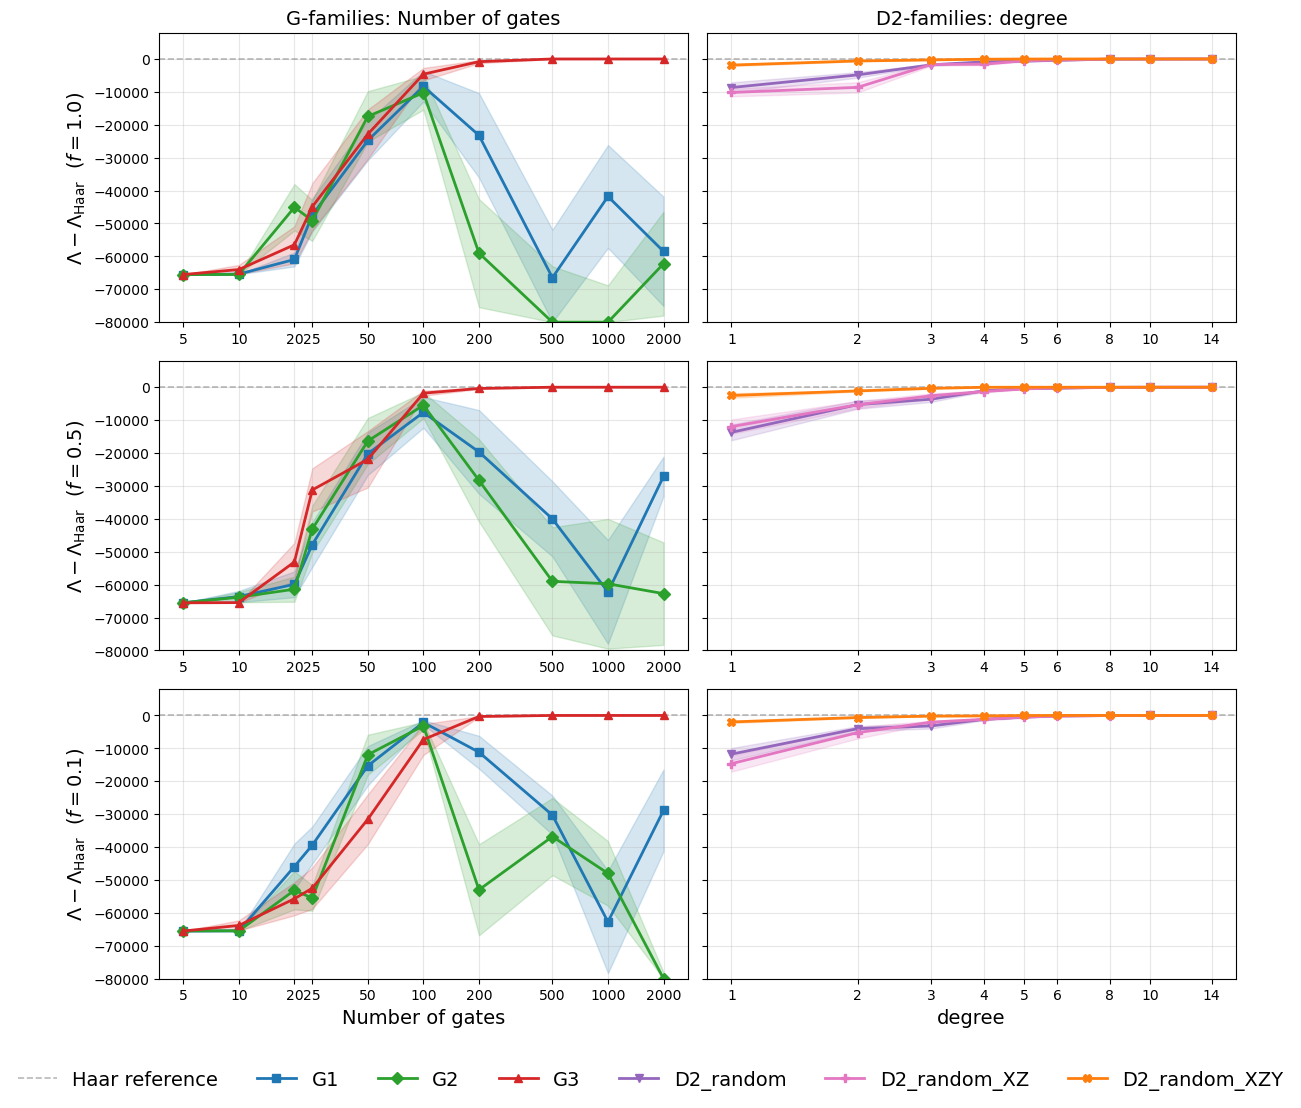

In [13]:
plot_ors_complexity_vs_fidelity(n=16, fs=(1.0, 0.5, 0.1), K_idx=3, ors_floor = -80000)

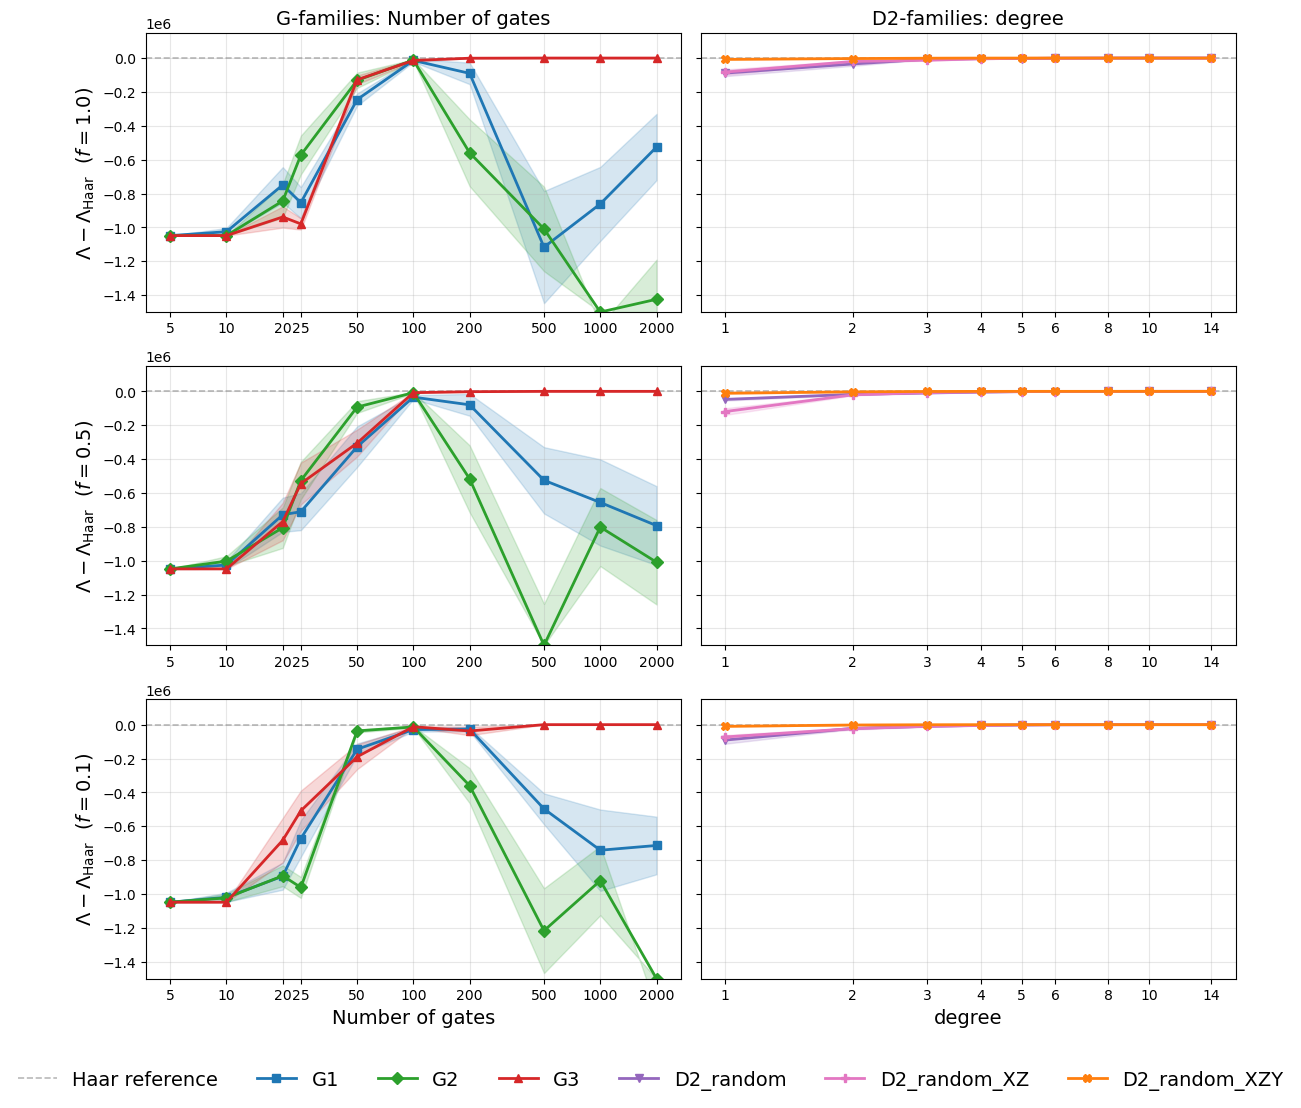

In [18]:
plot_ors_complexity_vs_fidelity(n=20, fs=(1.0, 0.5, 0.1), K_idx=3, ors_floor = -1500000)